# Embeddings Demo

This notebook generates sentence embeddings using `sentence-transformers` with the `all-MiniLM-L6-v2` model, plots the required 10x10 cosine similarity heatmap, and retrieves the top 2 matches for the query sentence.

In [1]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sentences = [
    "The opening batter anchored the chase with a calm half-century.",
    "The spinner deceived the batsman with a sharp turning delivery.",
    "The fielding side saved crucial runs with two diving stops near the boundary.",
    "The chef simmered the tomato sauce slowly to deepen the flavor.",
    "Fresh basil and olive oil lifted the pasta just before serving.",
    "The baker checked the bread temperature before taking it out of the oven.",
    "The security team rotated API keys after detecting suspicious login attempts.",
    "A phishing email tricked an employee into revealing corporate credentials.",
    "Multi-factor authentication reduced the impact of stolen passwords during the breach.",
    "The cook balanced the curry with yogurt and a squeeze of lemon."
]
query = "The bowler took three wickets in one over"

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences)
query_embedding = model.encode([query])
similarity_matrix = cosine_similarity(embeddings)
query_scores = cosine_similarity(query_embedding, embeddings)[0]
df = pd.DataFrame({"sentence_number": range(1, 11), "sentence": sentences})
df

sentence_number,sentence
1,The opening batter anchored the chase with a calm half-century.
2,The spinner deceived the batsman with a sharp turning delivery.
3,The fielding side saved crucial runs with two diving stops near the boundary.
4,The chef simmered the tomato sauce slowly to deepen the flavor.
5,Fresh basil and olive oil lifted the pasta just before serving.
6,The baker checked the bread temperature before taking it out of the oven.
7,The security team rotated API keys after detecting suspicious login attempts.
8,A phishing email tricked an employee into revealing corporate credentials.
9,Multi-factor authentication reduced the impact of stolen passwords during the breach.
10,The cook balanced the curry with yogurt and a squeeze of lemon.


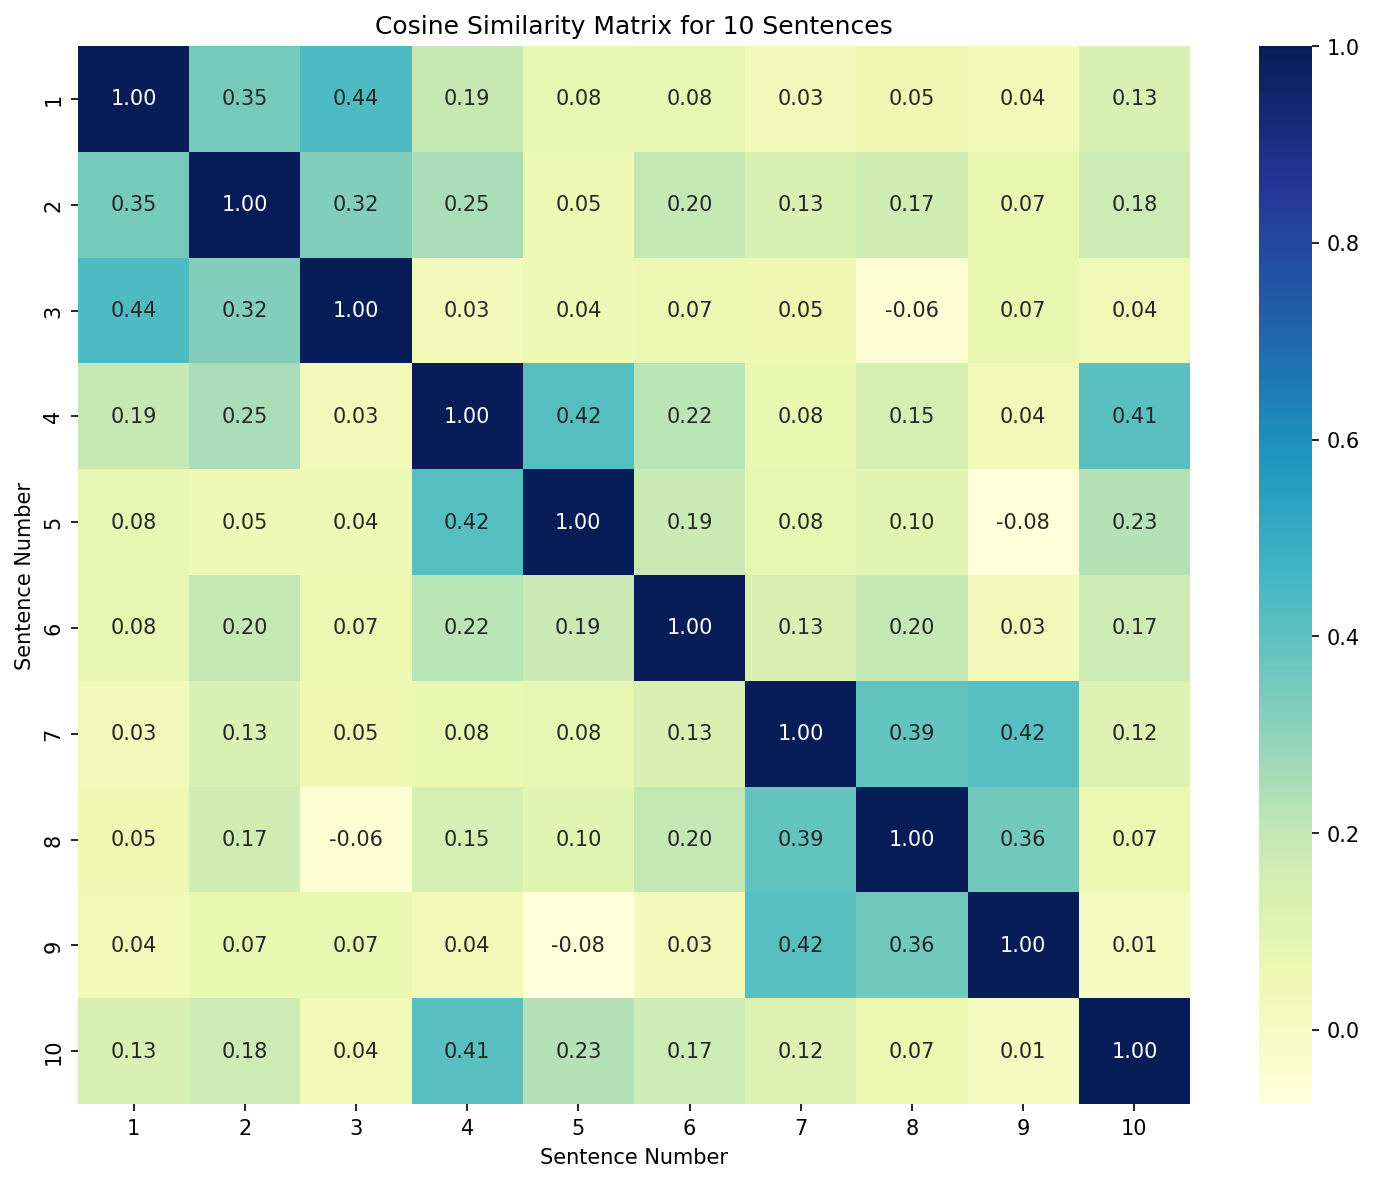

In [2]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap="YlGnBu", fmt=".2f", xticklabels=range(1, 11), yticklabels=range(1, 11))
plt.title("Cosine Similarity Matrix for 10 Sentences")
plt.xlabel("Sentence Number")
plt.ylabel("Sentence Number")
plt.tight_layout()
plt.show()

In [3]:
ranked = sorted(enumerate(query_scores, start=1), key=lambda x: x[1], reverse=True)[:2]
for idx, score in ranked:
    print(f"Sentence {idx}: {sentences[idx-1]}\nSimilarity Score: {score:.4f}\n")

Sentence 2: The spinner deceived the batsman with a sharp turning delivery.
Similarity Score: 0.5052

Sentence 3: The fielding side saved crucial runs with two diving stops near the boundary.
Similarity Score: 0.2915

